<a href="https://colab.research.google.com/github/Ritresh/Toxic_Comment_Classification_using_LSTMandNLP/blob/main/lstm_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# train csv
df_train = pd.read_csv('train.csv')

#test csv
df_test = pd.read_csv('test.csv')

# submission csv
df_submission = pd.read_csv('sample_submission.csv')

#test_labels csv
df_test_labels = pd.read_csv('test_labels.csv')

In [ ]:
df_train.head(3)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0


In [ ]:
df_test.head(3)

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."


In [ ]:
df_submission.head(3)

,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,0.5,0.5,0.5,0.5,0.5,0.5
1,0000247867823ef7,0.5,0.5,0.5,0.5,0.5,0.5
2,00013b17ad220c46,0.5,0.5,0.5,0.5,0.5,0.5


In [ ]:
df_test_labels.head(3)

,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,-1,-1,-1,-1,-1,-1
1,0000247867823ef7,-1,-1,-1,-1,-1,-1
2,00013b17ad220c46,-1,-1,-1,-1,-1,-1


# **Starting to work on train**

In [ ]:
df_train.head(4)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0


In [ ]:
df_copy = df_train.copy(deep=True)

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [ ]:
# check fot the dupliacte values

df_copy.duplicated().sum()

np.int64(0)

# **EDA**

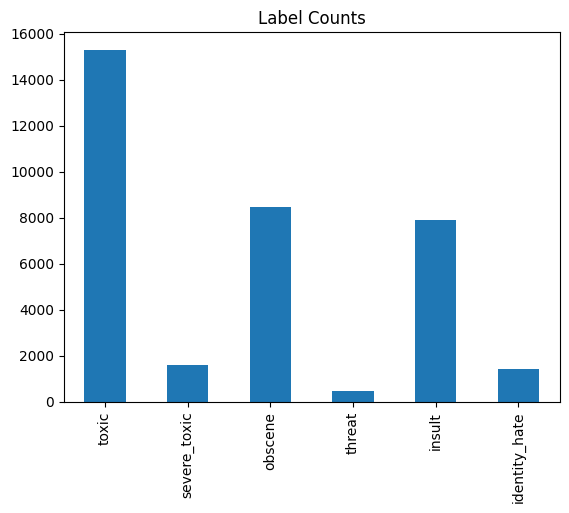

In [ ]:
import matplotlib.pyplot as plt
labels = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']

df_copy[labels].sum().plot(kind='bar')
plt.title('Label Counts')
plt.show()

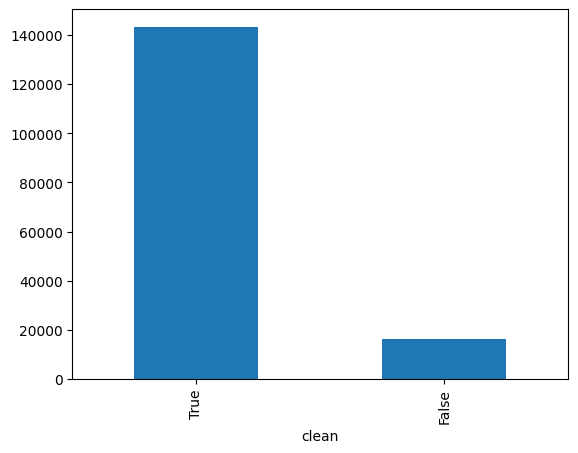

In [ ]:
# Clean vs Toxic comments
df_copy['clean'] = (df_copy[labels].sum(axis=1)==0)
df_copy['clean'].value_counts().plot(kind='bar')
plt.show()

In [ ]:
# top 10 most used type comments
df_copy[labels].value_counts().head(10)

toxic  severe_toxic  obscene  threat  insult  identity_hate
0      0             0        0       0       0                143346
1      0             0        0       0       0                  5666
                     1        0       1       0                  3800
                                      0       0                  1758
                     0        0       1       0                  1215
       1             1        0       1       0                   989
       0             1        0       1       1                   618
0      0             1        0       0       0                   317
                     0        0       1       0                   301
1      1             1        0       1       1                   265
Name: count, dtype: int64

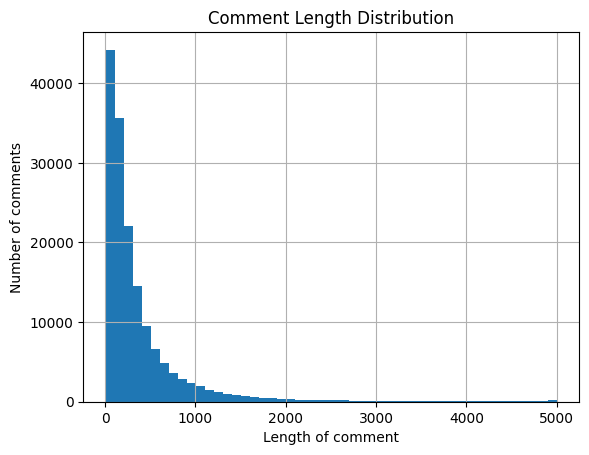

In [ ]:
# Length of the sentences
import matplotlib.pyplot as plt

df_copy['length'] = df_copy['comment_text'].apply(len)
df_copy['length'].hist(bins=50)
plt.title("Comment Length Distribution")
plt.xlabel("Length of comment")
plt.ylabel("Number of comments")
plt.show()

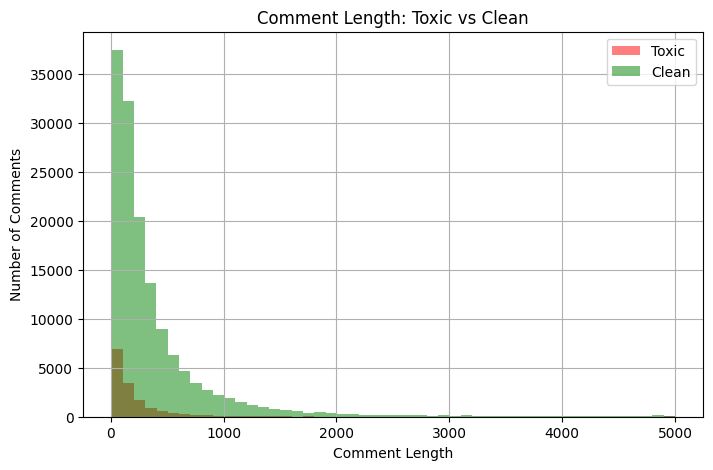

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
df_copy[df_copy['toxic']==1]['length'].hist(
    bins=50,
    alpha=0.5,
    color='red',
    label='Toxic'
)
df_copy[df_copy['toxic']==0]['length'].hist(
    bins=50,
    alpha=0.5,
    color='green',
    label='Clean'
)

plt.title("Comment Length: Toxic vs Clean")
plt.xlabel("Comment Length")
plt.ylabel("Number of Comments")
plt.legend()
plt.show()

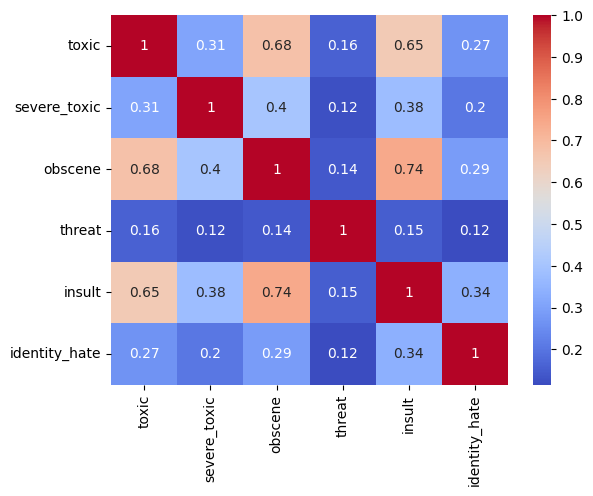

In [ ]:
#corelation b/w labels

import seaborn as sns
sns.heatmap(df_copy[labels].corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
from collections import Counter
import pandas as pd

labels = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']
top_words_dict = {}

for label in labels:
    text = " ".join(df_copy[df_copy[label] == 1]['comment_text'])
    words = text.split()
    common_words = Counter(words).most_common(15)
    top_words_dict[label] = [w[0] for w in common_words]

top_words_df = pd.DataFrame(top_words_dict)
top_words_df

,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,you,YOU,you,I,you,NIGGER
1,a,fuck,a,DIE,a,a
2,the,I,I,you,I,you
3,I,you,the,ass.,the,is
4,to,FUCK,and,to,and,FAT
5,and,a,to,WILL,YOU,JEW
6,is,SUCK,YOU,and,to,I
7,of,SHIT,of,You,is,and
8,YOU,THE,is,your,of,the
9,your,and,fuck,the,your,to


In [ ]:
from collections import Counter
import pandas as pd

labels = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']
top_words_dict = {}

for label in labels:
    text = " ".join(df_copy[df_copy[label] == 0]['comment_text'])
    words = text.split()
    common_words = Counter(words).most_common(15)
    top_words_dict[label] = [w[0] for w in common_words]

top_words_df = pd.DataFrame(top_words_dict)
top_words_df

,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,the,the,the,the,the,the
1,to,to,to,to,to,to
2,of,of,of,of,of,of
3,and,and,and,and,and,and
4,a,a,a,a,a,a
5,I,I,I,I,I,I
6,is,is,is,is,is,is
7,you,you,you,you,you,you
8,that,that,that,that,that,that
9,in,in,in,in,in,in


# **Seperate Feature & Target**

In [ ]:
# Feature and Target
labels = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']
X = df_copy['comment_text']
y = df_copy[labels]

In [ ]:
X

,comment_text
0,Explanation\nWhy the edits made under my usern...
1,D'aww! He matches this background colour I'm s...
2,"Hey man, I'm really not trying to edit war. It..."
3,"""\nMore\nI can't make any real suggestions on ..."
4,"You, sir, are my hero. Any chance you remember..."
...,...
159566,""":::::And for the second time of asking, when ..."
159567,You should be ashamed of yourself \n\nThat is ...
159568,"Spitzer \n\nUmm, theres no actual article for ..."
159569,And it looks like it was actually you who put ...


In [ ]:
y

,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
...,...,...,...,...,...,...
159566,0,0,0,0,0,0
159567,0,0,0,0,0,0
159568,0,0,0,0,0,0
159569,0,0,0,0,0,0


In [ ]:
# vocabulary size

MAX_FEATURES = 200000
SEQUENCE_LENGTH = 1800

In [ ]:
#TextVectorization remove punction by there own
from tensorflow.keras.layers import TextVectorization #typeignore

vectorizer = TextVectorization(max_tokens=MAX_FEATURES,
                               output_sequence_length=SEQUENCE_LENGTH,
                               output_mode='int')

In [ ]:
# adapt = learn vocabulary

vectorizer.adapt(X.values)

In [ ]:
vectorizer

In [ ]:
# Replace each word with its index
# Pad / trim to fixed length

vectorizer_text = vectorizer(X.values)

In [ ]:
vectorizer_text

In [ ]:
import tensorflow as tf
dataset = tf.data.Dataset.from_tensor_slices((vectorizer_text, y))
dataset = dataset.cache()
dataset = dataset.shuffle(160000)
dataset = dataset.batch(16)
dataset = dataset.prefetch(tf.data.AUTOTUNE)

In [ ]:
# now seperate the train, test and validation data

# Calculate the number of batches for each split
total_batches = dataset.cardinality().numpy()
train_size = int(total_batches * 0.7)
val_size = int(total_batches * 0.1)
test_size = total_batches - train_size - val_size

train = dataset.take(train_size)
val = dataset.skip(train_size).take(val_size)
test = dataset.skip(train_size + val_size).take(test_size)

# **Create an LSTM models**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding, Bidirectional

In [ ]:
model = Sequential()

# Create an embedding layer
model.add(Embedding(input_dim=MAX_FEATURES+1, output_dim=32, input_length=SEQUENCE_LENGTH))

# adding the Bidirectrinal layers
model.add(Bidirectional(LSTM(32, activation='tanh')))

# Dense layers
model.add(Dense(128, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))

# Final layer
model.add(Dense(6, activation='sigmoid'))

In [ ]:
# now compile

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
model.build(input_shape=(None, SEQUENCE_LENGTH))

model.summary()

In [ ]:
# history = model.fit(train, epochs=1, validation_data=val)

In [ ]:
import numpy as np

df_copy.columns[2:]

In [ ]:
def predict_comment(text):
    input_text = vectorizer(tf.constant([text]))
    res = model.predict(input_text)[0]
    return res


res = predict_comment("You freaking suck! I am going to hit you.")

print(res)
print((res > 0.5).astype(int))
print(res.shape)

# Displaying the results with labels
import pandas as pd

labels = df_copy.columns[2:]
result_df = pd.DataFrame({'Label': labels, 'Probability': res, 'Prediction': (res > 0.5).astype(int)})
display(result_df)

# ***Create a pickle file***